# V_CRG_STUDENT_COURSE — Preprocessing V5

Scope:
- Work only on `V_CRG_STUDENT_COURSE`.
- Load raw Parquet.
- Preserve raw data and original ID values.
- `is_last_try` is not used because it was removed from the source query.
- Calculate attempts manually per student-course.
- Do not overwrite original IDs.
- Create `*_raw`, `*_base`, `*_suffix`, `*_key` for ID columns.
- Do not assume pass/fail from `final_mark`.
- Official outcome comes only from `finish_status`.
- Apply explicit null-handling rules before creating the clean dataset.
- Do not build models.
- Do not build course difficulty.
- Do not build recommendation logic.


In [ ]:
from pathlib import Path
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

VERSION = "v5"

PROJECT_ROOT = Path(r"D:/AI/Real projects/Academic_Advisor")

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "v_crg_student_course_raw.parquet"
)

PREPROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "preprocessed"
    / "V_CRG_STUDENT_COURSE"
)

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "V_CRG_STUDENT_COURSE"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "V_CRG_STUDENT_COURSE"
)

PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("VERSION:", VERSION)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PATH:", RAW_PATH)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

assert RAW_PATH.exists(), f"Raw file not found: {RAW_PATH}"

VERSION: v5
PROJECT_ROOT: D:\AI\Real projects\Academic_Advisor
RAW_PATH: D:\AI\Real projects\Academic_Advisor\data\raw\v_crg_student_course_raw.parquet
PREPROCESSED_DIR: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE
FEATURES_DIR: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE
REPORTS_DIR: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE


## 1. Load raw Parquet file

This step loads the raw V5 Parquet file.  
No source values are changed here.


In [2]:
df_raw_loaded_v5 = pd.read_parquet(RAW_PATH)

print("Raw loaded shape:", df_raw_loaded_v5.shape)
display(df_raw_loaded_v5.head())
display(df_raw_loaded_v5.dtypes)

Raw loaded shape: (965467, 15)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A


student_course_id    float64
student_id           float64
course_id            float64
part_id              float64
grade_id             float64
final_mark           float64
points               float64
finish_status            str
course_name_sl           str
study_mode               str
degree_id            float64
degree_name_sl           str
faculty_id           float64
course_credits       float64
active                   str
dtype: object

In [3]:
assert isinstance(df_raw_loaded_v5, pd.DataFrame)
assert len(df_raw_loaded_v5) > 0, "Raw dataframe is empty."

print("Validation passed: raw Parquet loaded successfully.")

Validation passed: raw Parquet loaded successfully.


## 2. Standardize column names and validate required columns

Only column names are standardized to lowercase.  
Raw values remain unchanged.

Important:
- `is_last_try` is not required and is not used.


In [ ]:
df_raw_v5 = df_raw_loaded_v5.copy() ##  createa copy df

df_raw_v5.columns = (
    df_raw_v5.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

required_raw_columns_v5 = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "final_mark",
    "points",
    "finish_status",
    "course_name_sl",
    "study_mode",
    "degree_id",
    "degree_name_sl",
    "faculty_id",
    "course_credits",
    "active",
]

missing_required_columns_v5 = sorted(set(required_raw_columns_v5) - set(df_raw_v5.columns))
extra_columns_v5 = sorted(set(df_raw_v5.columns) - set(required_raw_columns_v5))

print("Missing required columns:", missing_required_columns_v5)
print("Extra source columns:", extra_columns_v5)

assert len(missing_required_columns_v5) == 0, f"Missing columns: {missing_required_columns_v5}"

df_raw_v5 = df_raw_v5[required_raw_columns_v5].copy() ## re assign with the required column 

print("Raw selected shape:", df_raw_v5.shape)
display(df_raw_v5.head())

Missing required columns: []
Extra source columns: []
Raw selected shape: (965467, 15)


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A


In [5]:
assert list(df_raw_v5.columns) == required_raw_columns_v5
assert df_raw_v5.shape[1] == len(required_raw_columns_v5)
assert "is_last_try" not in df_raw_v5.columns, "is_last_try should not be used in V5 workflow."

print("Validation passed: all required columns exist and selected.")

Validation passed: all required columns exist and selected.


## 3. Save raw profile report

This report gives a quick overview of row count, dtype, nulls, and unique values per column.


In [ ]:
raw_profile_report_v5 = pd.DataFrame({ ## create a profile report for the raw data from the copied df
    "column": df_raw_v5.columns,
    "dtype": [str(df_raw_v5[col].dtype) for col in df_raw_v5.columns],
    "row_count": len(df_raw_v5),
    "non_null_count": [int(df_raw_v5[col].notna().sum()) for col in df_raw_v5.columns],
    "null_count": [int(df_raw_v5[col].isna().sum()) for col in df_raw_v5.columns],
    "null_ratio": [float(df_raw_v5[col].isna().mean()) for col in df_raw_v5.columns],
    "unique_count": [int(df_raw_v5[col].nunique(dropna=True)) for col in df_raw_v5.columns],
})

raw_profile_report_path_v5 = REPORTS_DIR / "raw_profile_report_v5.csv"
raw_profile_report_v5.to_csv(raw_profile_report_path_v5, index=False, encoding="utf-8-sig")

display(raw_profile_report_v5)
print("Saved:", raw_profile_report_path_v5)

,column,dtype,row_count,non_null_count,null_count,null_ratio,unique_count
0,student_course_id,float64,965467,965467,0,0.000000,960175
1,student_id,float64,965467,965467,0,0.000000,16686
2,course_id,float64,965467,965466,1,0.000001,1114
3,part_id,float64,965467,965466,1,0.000001,67
4,grade_id,float64,965467,810710,154757,0.160292,57
5,final_mark,float64,965467,810284,155183,0.160734,101
6,points,float64,965467,810710,154757,0.160292,18
7,finish_status,str,965467,810693,154774,0.160310,13
8,course_name_sl,str,965467,965466,1,0.000001,938
9,study_mode,str,965467,965467,0,0.000000,1


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\raw_profile_report_v5.csv


In [7]:
assert raw_profile_report_path_v5.exists()
assert len(raw_profile_report_v5) == len(required_raw_columns_v5)

print("Validation passed: raw profile report saved.")

Validation passed: raw profile report saved.


## 4. Save null report

This report shows missing values per column.  
It is important before deciding archive/drop or critical issues.


In [8]:
null_report_v5 = (
    df_raw_v5  ## Calculate null counts by column and the output is series while the coulumn become the index so ireset the index and give it the name needed
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "null_count"})
)

null_report_v5["row_count"] = len(df_raw_v5)
null_report_v5["null_ratio"] = null_report_v5["null_count"] / len(df_raw_v5)

null_report_v5 = null_report_v5.sort_values("null_count", ascending=False).reset_index(drop=True)

null_report_path_v5 = REPORTS_DIR / "null_report_v5.csv"
null_report_v5.to_csv(null_report_path_v5, index=False, encoding="utf-8-sig")

display(null_report_v5)
print("Saved:", null_report_path_v5)

,column,null_count,row_count,null_ratio
0,final_mark,155183,965467,0.160734
1,finish_status,154774,965467,0.160310
2,grade_id,154757,965467,0.160292
3,points,154757,965467,0.160292
4,degree_name_sl,121978,965467,0.126341
5,degree_id,34,965467,0.000035
6,faculty_id,34,965467,0.000035
7,course_credits,1,965467,0.000001
8,course_name_sl,1,965467,0.000001
9,part_id,1,965467,0.000001


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\null_report_v5.csv


In [9]:
assert null_report_path_v5.exists()
assert set(null_report_v5["column"]) == set(required_raw_columns_v5)

print("Validation passed: null report saved.")

Validation passed: null report saved.


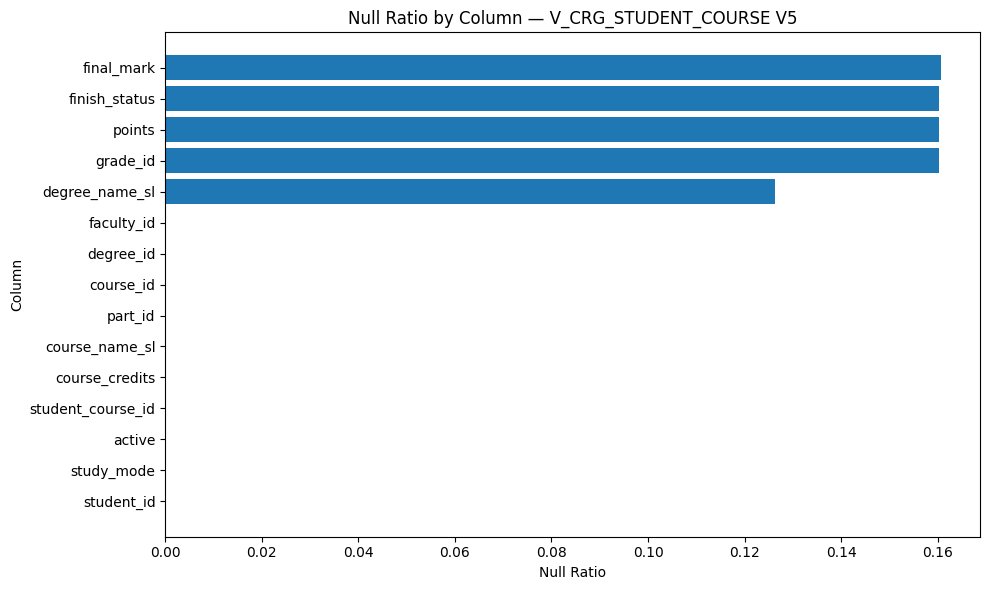

In [10]:
plot_df = null_report_v5.sort_values("null_ratio", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["column"], plot_df["null_ratio"])
plt.title("Null Ratio by Column — V_CRG_STUDENT_COURSE V5")
plt.xlabel("Null Ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

## 5. Save finish_status distribution report

`finish_status` is the only official source for academic outcome.  
`final_mark >= 50` is not used as pass logic.


In [ ]:
finish_status_distribution_v5 = (
    df_raw_v5["finish_status"] ## take only one column and make it a string type and strip ,upper ut ...
    .astype("string")
    .str.strip()
    .str.upper()
    .fillna("<NULL>")
    .value_counts(dropna=False)
    .reset_index()
)

finish_status_distribution_v5.columns = ["finish_status", "count"]
finish_status_distribution_v5["row_count"] = len(df_raw_v5)
finish_status_distribution_v5["ratio"] = finish_status_distribution_v5["count"] / len(df_raw_v5)

finish_status_distribution_path_v5 = REPORTS_DIR / "finish_status_distribution_v5.csv"
finish_status_distribution_v5.to_csv(
    finish_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(finish_status_distribution_v5)
print("Saved:", finish_status_distribution_path_v5)

,finish_status,count,row_count,ratio
0,P,618606,965467,0.640732
1,<NULL>,154774,965467,0.16031
2,F,96787,965467,0.100249
3,W,35982,965467,0.037269
4,T,19525,965467,0.020223
5,Z,13495,965467,0.013978
6,ST,12193,965467,0.012629
7,X,10584,965467,0.010963
8,D,1560,965467,0.001616
9,FA,1105,965467,0.001145


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\finish_status_distribution_v5.csv


In [12]:
assert finish_status_distribution_path_v5.exists()
assert finish_status_distribution_v5["count"].sum() == len(df_raw_v5)

print("Validation passed: finish_status distribution saved.")

Validation passed: finish_status distribution saved.


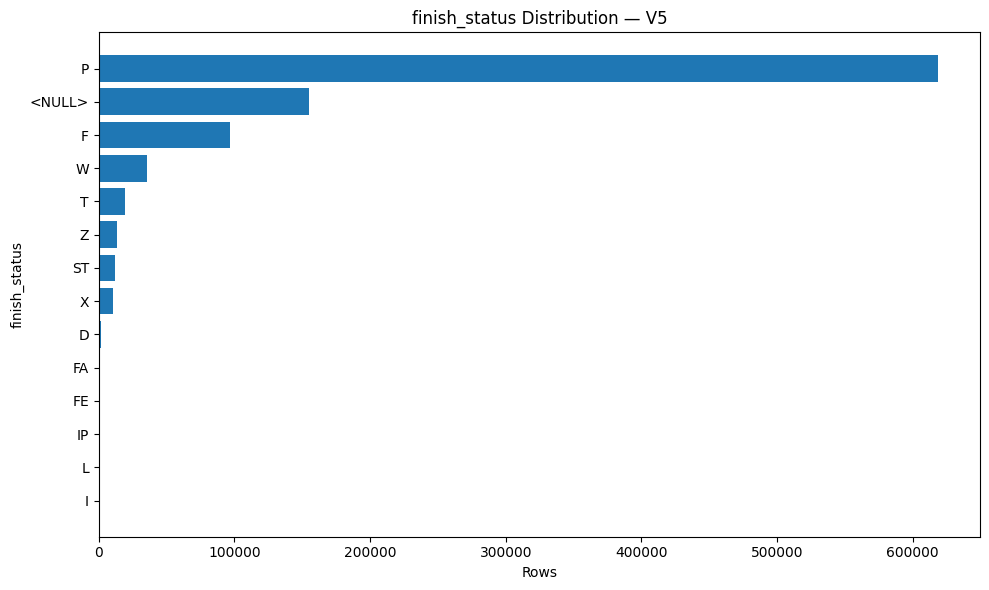

In [13]:
plot_df = finish_status_distribution_v5.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["finish_status"], plot_df["count"])
plt.title("finish_status Distribution — V5")
plt.xlabel("Rows")
plt.ylabel("finish_status")
plt.tight_layout()
plt.show()

## 6. Numeric validation without stopping the notebook

Rules:
- `final_mark` should be integer-like.
- `course_credits` may contain unexpected fractional values; do not round automatically.
- `points` is float and remains raw.

Important:
- If `course_credits` has fractional values, report them and continue.
- Do not manually fill or modify `course_credits`.


In [ ]:
def integer_like_report(df: pd.DataFrame, column: str) -> dict: ## Make sure the number is integer able or float 64  
    numeric = pd.to_numeric(df[column], errors="coerce")
    non_null_numeric = numeric.dropna()
    fractional_mask = (non_null_numeric % 1) != 0

    return {
        "column": column,
        "source_dtype": str(df[column].dtype),
        "non_null_count": int(df[column].notna().sum()),
        "numeric_count": int(non_null_numeric.shape[0]),
        "non_numeric_or_null_count": int(df[column].shape[0] - non_null_numeric.shape[0]),
        "fractional_count": int(fractional_mask.sum()),
        "fractional_ratio": float(fractional_mask.mean()) if len(non_null_numeric) > 0 else 0,
    }


numeric_validation_report_v5 = pd.DataFrame([
    integer_like_report(df_raw_v5, "final_mark"),
    integer_like_report(df_raw_v5, "course_credits"),
])

points_numeric_v5 = pd.to_numeric(df_raw_v5["points"], errors="coerce")

points_report_v5 = pd.DataFrame([{
    "column": "points",
    "source_dtype": str(df_raw_v5["points"].dtype),
    "non_null_count": int(df_raw_v5["points"].notna().sum()),
    "numeric_count": int(points_numeric_v5.notna().sum()),
    "non_numeric_or_null_count": int(df_raw_v5["points"].shape[0] - points_numeric_v5.notna().sum()),
    "fractional_count": np.nan,
    "fractional_ratio": np.nan,
}])

numeric_validation_report_v5 = pd.concat(
    [numeric_validation_report_v5, points_report_v5],
    ignore_index=True
)

numeric_validation_report_path_v5 = REPORTS_DIR / "numeric_validation_report_v5.csv"
numeric_validation_report_v5.to_csv(
    numeric_validation_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(numeric_validation_report_v5)
print("Saved:", numeric_validation_report_path_v5)

,column,source_dtype,non_null_count,numeric_count,non_numeric_or_null_count,fractional_count,fractional_ratio
0,final_mark,float64,810284,810284,155183,0.0,0.000000
1,course_credits,float64,965466,965466,1,9407.0,0.009743
2,points,float64,810710,810710,154757,NaN,NaN


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\numeric_validation_report_v5.csv


In [ ]:
final_mark_fractional = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("final_mark"),
    "fractional_count"
].iloc[0]

course_credits_fractional = numeric_validation_report_v5.loc[
    numeric_validation_report_v5["column"].eq("course_credits"),
    "fractional_count"
].iloc[0]

assert final_mark_fractional == 0, "final_mark has fractional values."

if course_credits_fractional > 0:
    print("WARNING: course_credits has fractional values.")
    print("These rows will be reported and flagged. No rounding will be applied.")
else:
    print("course_credits is integer-like.")

assert numeric_validation_report_path_v5.exists()

print("Validation passed: final_mark is integer-like. course_credits inspected.")

These rows will be reported and flagged. No rounding will be applied.
Validation passed: final_mark is integer-like. course_credits inspected.


## 7. Inspect fractional course_credits

These rows are saved for inspection instead of being silently changed.


In [16]:
course_credits_numeric_v5 = pd.to_numeric(df_raw_v5["course_credits"], errors="coerce")

fractional_course_credits_mask_v5 = (
    course_credits_numeric_v5.notna()
    & ((course_credits_numeric_v5 % 1) != 0)
)

fractional_course_credits_rows_v5 = df_raw_v5[fractional_course_credits_mask_v5].copy()

fractional_course_credits_distribution_v5 = (
    fractional_course_credits_rows_v5["course_credits"]
    .value_counts(dropna=False)
    .reset_index()
)

fractional_course_credits_distribution_v5.columns = ["course_credits", "count"]
fractional_course_credits_distribution_v5["row_count"] = len(df_raw_v5)
fractional_course_credits_distribution_v5["ratio"] = (
    fractional_course_credits_distribution_v5["count"] / len(df_raw_v5)
)

fractional_course_credits_rows_path_v5 = REPORTS_DIR / "fractional_course_credits_rows_v5.csv"
fractional_course_credits_distribution_path_v5 = (
    REPORTS_DIR / "fractional_course_credits_distribution_v5.csv"
)

fractional_course_credits_rows_v5.to_csv(
    fractional_course_credits_rows_path_v5,
    index=False,
    encoding="utf-8-sig"
)

fractional_course_credits_distribution_v5.to_csv(
    fractional_course_credits_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(fractional_course_credits_distribution_v5)
display(fractional_course_credits_rows_v5.head(50))

print("Fractional course_credits rows:", len(fractional_course_credits_rows_v5))
print("Saved:", fractional_course_credits_rows_path_v5)
print("Saved:", fractional_course_credits_distribution_path_v5)

,course_credits,count,row_count,ratio
0,4.5,9407,965467,0.009743


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
47840,845319.111,3617.111,705.111,20141.0,984.111,53.0,1.50,P,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A
47841,845320.111,3617.111,704.111,20141.0,981.111,66.0,2.25,P,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A
58002,861992.111,3625.111,704.111,20141.0,980.111,74.0,2.50,P,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A
58003,861993.111,3625.111,705.111,20141.0,982.111,61.0,2.00,P,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A
58007,861997.111,3599.111,704.111,20141.0,981.111,68.0,2.25,P,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A
58008,861998.111,3599.111,705.111,20141.0,982.111,63.0,2.00,P,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A
58020,863050.111,3541.111,705.111,20141.0,985.111,42.0,0.00,F,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A
58021,863051.111,3541.111,704.111,20141.0,984.111,50.0,1.50,P,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A
58027,863057.111,3356.111,705.111,20141.0,985.111,43.0,0.00,F,طب التوليد,C,2.111,دكتور في الطب,2.111,4.5,A
58028,863058.111,3356.111,704.111,20141.0,985.111,39.0,0.00,F,أمراض الأطفال (1),C,2.111,دكتور في الطب,2.111,4.5,A


Fractional course_credits rows: 9407
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\fractional_course_credits_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\fractional_course_credits_distribution_v5.csv


In [17]:
assert fractional_course_credits_rows_path_v5.exists()
assert fractional_course_credits_distribution_path_v5.exists()

print("Validation passed: fractional course_credits rows reported.")

Validation passed: fractional course_credits rows reported.


## 8. Drop exact duplicate rows from working dataframe

Raw data remains unchanged in `df_raw_v5`.  
Exact duplicate rows are reported, then removed only from `df_work_v5`.


In [ ]:
duplicate_full_row_mask_v5 = df_raw_v5.duplicated(keep="first")

df_duplicate_rows_v5 = df_raw_v5[duplicate_full_row_mask_v5].copy()

duplicate_rows_path_v5 = REPORTS_DIR / "duplicate_rows_v5.csv"
df_duplicate_rows_v5.to_csv(duplicate_rows_path_v5, index=False, encoding="utf-8-sig")

df_work_v5 = df_raw_v5.drop_duplicates(keep="first").copy()  #### define the work df *** *** *** freedom 
df_work_v5["_source_row_number_v5"] = np.arange(len(df_work_v5)) ### like a new index

print("Raw rows before duplicate removal:", len(df_raw_v5))
print("Exact duplicate rows removed:", len(df_duplicate_rows_v5))
print("Rows after duplicate removal:", len(df_work_v5))
print("Saved:", duplicate_rows_path_v5)

display(df_duplicate_rows_v5.head(50))

Raw rows before duplicate removal: 965467
Exact duplicate rows removed: 5292
Rows after duplicate removal: 960175
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\duplicate_rows_v5.csv


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active
370145,1324400.111,14858.111,1162.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 3,C,22.111,إدارة (اختصاص عام),7.111,0.0,A
370147,1324401.111,13993.111,1160.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A
370149,1324402.111,14643.111,1160.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 1,C,2.111,دكتور في الطب,2.111,0.0,A
370151,1324403.111,14669.111,1160.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 1,C,2.111,دكتور في الطب,2.111,0.0,A
370153,1324404.111,14669.111,1161.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 2,C,2.111,دكتور في الطب,2.111,0.0,A
370155,1324405.111,14669.111,1162.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 3,C,2.111,دكتور في الطب,2.111,0.0,A
370157,1324406.111,14658.111,1160.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A
370159,1324407.111,14706.111,1160.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 1,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A
370161,1324408.111,14706.111,1161.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 2,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A
370163,1324409.111,14706.111,1162.111,20192.0,1004.111,0.0,0.0,X,الانكليزية التحضيرية 3,C,1.111,إجازة دكتور في طب الأسنان,3.111,0.0,A


In [19]:
assert len(df_work_v5) + len(df_duplicate_rows_v5) == len(df_raw_v5)
assert df_work_v5[required_raw_columns_v5].duplicated().sum() == 0
assert duplicate_rows_path_v5.exists()

print("Validation passed: exact duplicates reported and removed from working dataframe.")

Validation passed: exact duplicates reported and removed from working dataframe.


## 9. Define finish_status and null-handling rules

Current decision:

Keep:
- `P`
- `F`
- `FA`
- `FE`
- `W`

Archive/drop:
- `T`
- `X`
- `IP`
- `L`
- `Z`
- `D`
- `I`
- `ST`
- null `finish_status`

Also:
- Treat `F`, `FA`, and `FE` as the same fail family.
- `final_mark` null can be filled with 0 only for `F`, `FA`, `FE`, `W`, `IP`, `Z`.
- `points` remains raw; only its range is inspected.
- `grade_id` remains raw; do not interpret it without `grade_version_id`.
- `course_credits` null is not manually filled.
- `course_credits == 24` is archive/drop.
- `course_credits == 0` is archive/drop in this notebook by default.


In [20]:
KEEP_STATUSES_V5 = {"P", "F", "FA", "FE", "W"}

PASS_STATUSES_V5 = {"P"}

FAIL_STATUSES_V5 = {"F", "FA", "FE"}

WITHDRAWN_STATUSES_V5 = {"W"}

DROP_ARCHIVE_STATUSES_V5 = {"T", "X", "IP", "L", "Z", "D", "I", "ST"}

FINAL_MARK_ZERO_FILL_STATUSES_V5 = {"F", "FA", "FE", "W", "IP", "Z"}

KNOWN_STATUSES_V5 = KEEP_STATUSES_V5 | DROP_ARCHIVE_STATUSES_V5

DROP_ZERO_COURSE_CREDITS_V5 = True

print("Keep statuses:", sorted(KEEP_STATUSES_V5))
print("Pass statuses:", sorted(PASS_STATUSES_V5))
print("Fail statuses:", sorted(FAIL_STATUSES_V5))
print("Withdrawn statuses:", sorted(WITHDRAWN_STATUSES_V5))
print("Drop/archive statuses:", sorted(DROP_ARCHIVE_STATUSES_V5))
print("Final mark zero-fill statuses:", sorted(FINAL_MARK_ZERO_FILL_STATUSES_V5))
print("DROP_ZERO_COURSE_CREDITS_V5:", DROP_ZERO_COURSE_CREDITS_V5)

Keep statuses: ['F', 'FA', 'FE', 'P', 'W']
Pass statuses: ['P']
Fail statuses: ['F', 'FA', 'FE']
Withdrawn statuses: ['W']
Drop/archive statuses: ['D', 'I', 'IP', 'L', 'ST', 'T', 'X', 'Z']
Final mark zero-fill statuses: ['F', 'FA', 'FE', 'IP', 'W', 'Z']
DROP_ZERO_COURSE_CREDITS_V5: True


In [21]:
assert KEEP_STATUSES_V5 == {"P", "F", "FA", "FE", "W"}
assert FAIL_STATUSES_V5 == {"F", "FA", "FE"}
assert "T" in DROP_ARCHIVE_STATUSES_V5
assert "IP" in DROP_ARCHIVE_STATUSES_V5
assert "W" in KEEP_STATUSES_V5
assert "Z" in FINAL_MARK_ZERO_FILL_STATUSES_V5

print("Validation passed: finish_status and null-handling rules are active.")

Validation passed: finish_status and null-handling rules are active.


## 10. Create flagged dataframe after duplicate removal

This dataframe is the base for null handling, cleaning, and reporting.  
Original source columns are preserved.


In [ ]:
df_flagged_v5 = df_work_v5.copy() ## flag df 

df_flagged_v5["finish_status_clean"] = (
    df_flagged_v5["finish_status"]
    .astype("string")
    .str.strip()
    .str.upper()
)

df_flagged_v5["final_mark_numeric_v5"] = (
    pd.to_numeric(df_flagged_v5["final_mark"], errors="coerce")
    .astype("float64")
)

df_flagged_v5["points_float"] = (
    pd.to_numeric(df_flagged_v5["points"], errors="coerce")
    .astype("float64")
)

df_flagged_v5["course_credits_num"] = (
    pd.to_numeric(df_flagged_v5["course_credits"], errors="coerce")
    .astype("float64")
)
 
df_flagged_v5["course_credits_int"] = np.where(
    df_flagged_v5["course_credits_num"].notna()
    & ((df_flagged_v5["course_credits_num"] % 1) == 0),
    df_flagged_v5["course_credits_num"],
    np.nan
)

df_flagged_v5["course_credits_int"] = (
    pd.Series(df_flagged_v5["course_credits_int"], index=df_flagged_v5.index)
    .astype("Int64")
)

df_flagged_v5["has_fractional_course_credits"] = (
    df_flagged_v5["course_credits_num"].notna()
    & ((df_flagged_v5["course_credits_num"] % 1) != 0)
)

df_flagged_v5["course_name_clean"] = (
    df_flagged_v5["course_name_sl"]
    .astype("string")
    .str.strip()
)

df_flagged_v5["degree_name_clean"] = (
    df_flagged_v5["degree_name_sl"]
    .astype("string")
    .str.strip()
)

df_flagged_v5["study_mode_clean"] = (
    df_flagged_v5["study_mode"]
    .astype("string")
    .str.strip()
    .str.upper()
)

display(df_flagged_v5.head(20))

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,finish_status_clean,final_mark_numeric_v5,points_float,course_credits_num,course_credits_int,has_fractional_course_credits,course_name_clean,degree_name_clean,study_mode_clean
0,466289.111,1491.111,153.111,20111.0,684.111,37.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,0,F,37.0,0.00,2.0,2,False,التحليل الاقتصادي الجزئي,إدارة الأعمال,C
1,466290.111,1491.111,152.111,20111.0,684.111,48.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A,1,F,48.0,0.00,2.0,2,False,مدخل الى القانون,إدارة الأعمال,C
2,466291.111,1491.111,150.111,20111.0,679.111,72.0,2.50,P,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A,2,P,72.0,2.50,3.0,3,False,مهارات الحاسوب 1,إدارة الأعمال,C
3,466292.111,1491.111,149.111,20111.0,676.111,86.0,3.25,P,اللغة العربية,C,19.111,إدارة الأعمال,7.111,2.0,A,3,P,86.0,3.25,2.0,2,False,اللغة العربية,إدارة الأعمال,C
4,466293.111,1492.111,153.111,20111.0,684.111,12.0,0.00,F,التحليل الاقتصادي الجزئي,C,19.111,إدارة الأعمال,7.111,2.0,A,4,F,12.0,0.00,2.0,2,False,التحليل الاقتصادي الجزئي,إدارة الأعمال,C
5,466294.111,1492.111,150.111,20111.0,684.111,24.0,0.00,F,مهارات الحاسوب 1,C,19.111,إدارة الأعمال,7.111,3.0,A,5,F,24.0,0.00,3.0,3,False,مهارات الحاسوب 1,إدارة الأعمال,C
6,466295.111,1492.111,154.111,20111.0,684.111,31.0,0.00,F,مبادئ المحاسبة 1,C,19.111,إدارة الأعمال,7.111,3.0,A,6,F,31.0,0.00,3.0,3,False,مبادئ المحاسبة 1,إدارة الأعمال,C
7,466296.111,1492.111,152.111,20111.0,684.111,37.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A,7,F,37.0,0.00,2.0,2,False,مدخل الى القانون,إدارة الأعمال,C
8,466297.111,1493.111,152.111,20111.0,684.111,32.0,0.00,F,مدخل الى القانون,C,19.111,إدارة الأعمال,7.111,2.0,A,8,F,32.0,0.00,2.0,2,False,مدخل الى القانون,إدارة الأعمال,C
9,466298.111,1493.111,155.111,20111.0,684.111,36.0,0.00,F,مبادئ الادارة,C,19.111,إدارة الأعمال,7.111,2.0,A,9,F,36.0,0.00,2.0,2,False,مبادئ الادارة,إدارة الأعمال,C


In [23]:
assert len(df_flagged_v5) == len(df_work_v5)
assert "finish_status_clean" in df_flagged_v5.columns
assert "course_credits_num" in df_flagged_v5.columns
assert "has_fractional_course_credits" in df_flagged_v5.columns
assert "is_last_try" not in df_flagged_v5.columns

print("Validation passed: flagged dataframe created after duplicate removal.")

Validation passed: flagged dataframe created after duplicate removal.


## 11. Apply explicit null-handling flags

Rules:
1. Any row with null `finish_status` is archive/drop.
2. If `finish_status` is null even with `final_mark = 0`, it is still archive/drop.
3. `final_mark` null is filled with 0 only for statuses `F`, `FA`, `FE`, `W`, `IP`, `Z`.
4. `points` remains raw; only range is inspected.
5. `grade_id` remains raw and is not interpreted.
6. `course_credits` null is not filled manually.
7. `course_name_sl` and `degree_name_sl` do not cause deletion directly.


In [ ]:
df_flagged_v5["finish_status_is_null_v5"] = df_flagged_v5["finish_status_clean"].isna() ## create flags 

df_flagged_v5["finish_status_null_without_grade_mark_points_v5"] = (
    df_flagged_v5["finish_status_is_null_v5"]
    & df_flagged_v5["grade_id"].isna()
    & df_flagged_v5["final_mark"].isna()
    & df_flagged_v5["points"].isna()
)

df_flagged_v5["finish_status_null_with_final_mark_zero_v5"] = (
    df_flagged_v5["finish_status_is_null_v5"]
    & df_flagged_v5["final_mark_numeric_v5"].eq(0)
)

df_flagged_v5["final_mark_was_filled_zero_v5"] = (
    df_flagged_v5["final_mark_numeric_v5"].isna()
    & df_flagged_v5["finish_status_clean"].isin(FINAL_MARK_ZERO_FILL_STATUSES_V5)
)

df_flagged_v5["final_mark_clean_v5"] = df_flagged_v5["final_mark_numeric_v5"]

df_flagged_v5.loc[
    df_flagged_v5["final_mark_was_filled_zero_v5"],
    "final_mark_clean_v5"
] = 0

df_flagged_v5["final_mark_clean_int_v5"] = (
    df_flagged_v5["final_mark_clean_v5"]
    .round()
    .astype("Int64")
)

df_flagged_v5["course_credits_is_null_v5"] = df_flagged_v5["course_credits_num"].isna()
df_flagged_v5["course_name_is_null_v5"] = df_flagged_v5["course_name_sl"].isna()
df_flagged_v5["degree_name_is_null_v5"] = df_flagged_v5["degree_name_sl"].isna()

display(df_flagged_v5[[
    "finish_status",
    "finish_status_clean",
    "grade_id",
    "final_mark",
    "final_mark_numeric_v5",
    "final_mark_clean_v5",
    "final_mark_was_filled_zero_v5",
    "points",
    "points_float",
    "course_credits",
    "course_credits_num",
    "course_credits_is_null_v5",
]].head(30))

,finish_status,finish_status_clean,grade_id,final_mark,final_mark_numeric_v5,final_mark_clean_v5,final_mark_was_filled_zero_v5,points,points_float,course_credits,course_credits_num,course_credits_is_null_v5
0,F,F,684.111,37.0,37.0,37.0,False,0.00,0.00,2.0,2.0,False
1,F,F,684.111,48.0,48.0,48.0,False,0.00,0.00,2.0,2.0,False
2,P,P,679.111,72.0,72.0,72.0,False,2.50,2.50,3.0,3.0,False
3,P,P,676.111,86.0,86.0,86.0,False,3.25,3.25,2.0,2.0,False
4,F,F,684.111,12.0,12.0,12.0,False,0.00,0.00,2.0,2.0,False
5,F,F,684.111,24.0,24.0,24.0,False,0.00,0.00,3.0,3.0,False
6,F,F,684.111,31.0,31.0,31.0,False,0.00,0.00,3.0,3.0,False
7,F,F,684.111,37.0,37.0,37.0,False,0.00,0.00,2.0,2.0,False
8,F,F,684.111,32.0,32.0,32.0,False,0.00,0.00,2.0,2.0,False
9,F,F,684.111,36.0,36.0,36.0,False,0.00,0.00,2.0,2.0,False


In [25]:
invalid_final_mark_fill_v5 = df_flagged_v5[
    df_flagged_v5["final_mark_was_filled_zero_v5"]
    & ~df_flagged_v5["finish_status_clean"].isin(FINAL_MARK_ZERO_FILL_STATUSES_V5)
]

assert len(invalid_final_mark_fill_v5) == 0, "final_mark was filled outside allowed statuses."

null_handling_report_v5 = pd.DataFrame([
    {
        "case": "finish_status_null_total",
        "count": int(df_flagged_v5["finish_status_is_null_v5"].sum()),
    },
    {
        "case": "finish_status_null_without_grade_mark_points",
        "count": int(df_flagged_v5["finish_status_null_without_grade_mark_points_v5"].sum()),
    },
    {
        "case": "finish_status_null_with_final_mark_zero",
        "count": int(df_flagged_v5["finish_status_null_with_final_mark_zero_v5"].sum()),
    },
    {
        "case": "final_mark_null_filled_zero_allowed_statuses",
        "count": int(df_flagged_v5["final_mark_was_filled_zero_v5"].sum()),
    },
    {
        "case": "course_credits_null_not_filled",
        "count": int(df_flagged_v5["course_credits_is_null_v5"].sum()),
    },
    {
        "case": "course_name_null_not_direct_drop",
        "count": int(df_flagged_v5["course_name_is_null_v5"].sum()),
    },
    {
        "case": "degree_name_null_not_direct_drop",
        "count": int(df_flagged_v5["degree_name_is_null_v5"].sum()),
    },
])

null_handling_report_v5["row_count"] = len(df_flagged_v5)
null_handling_report_v5["ratio"] = null_handling_report_v5["count"] / len(df_flagged_v5)

null_handling_report_path_v5 = REPORTS_DIR / "null_handling_report_v5.csv"
null_handling_report_v5.to_csv(null_handling_report_path_v5, index=False, encoding="utf-8-sig")

display(null_handling_report_v5)
print("Saved:", null_handling_report_path_v5)

assert null_handling_report_path_v5.exists()

print("Validation passed: null-handling rules applied and reported.")

,case,count,row_count,ratio
0,finish_status_null_total,154774,960175,0.161194
1,finish_status_null_without_grade_mark_points,154674,960175,0.161089
2,finish_status_null_with_final_mark_zero,98,960175,0.000102
3,final_mark_null_filled_zero_allowed_statuses,507,960175,0.000528
4,course_credits_null_not_filled,1,960175,0.000001
5,course_name_null_not_direct_drop,1,960175,0.000001
6,degree_name_null_not_direct_drop,121842,960175,0.126896


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\null_handling_report_v5.csv
Validation passed: null-handling rules applied and reported.


## 12. Inspect points range

`points` remains raw.  
This step only reports its numeric range and suspicious negative values.


In [ ]:
points_range_report_v5 = pd.DataFrame([{
    "metric": "points_float",
    "count": int(df_flagged_v5["points_float"].notna().sum()),
    "null_count": int(df_flagged_v5["points_float"].isna().sum()),
    "min": float(df_flagged_v5["points_float"].min()) if df_flagged_v5["points_float"].notna().any() else np.nan,
    "max": float(df_flagged_v5["points_float"].max()) if df_flagged_v5["points_float"].notna().any() else np.nan,
    "mean": float(df_flagged_v5["points_float"].mean()) if df_flagged_v5["points_float"].notna().any() else np.nan,
    "negative_count": int(df_flagged_v5["points_float"].lt(0).sum()),
}])

points_range_report_path_v5 = REPORTS_DIR / "points_range_report_v5.csv"
points_range_report_v5.to_csv(points_range_report_path_v5, index=False, encoding="utf-8-sig")

negative_points_rows_v5 = df_flagged_v5[df_flagged_v5["points_float"].lt(0)].copy() ## larger than 
negative_points_rows_path_v5 = REPORTS_DIR / "negative_points_rows_v5.csv"
negative_points_rows_v5.to_csv(negative_points_rows_path_v5, index=False, encoding="utf-8-sig")

display(points_range_report_v5)
print("Saved:", points_range_report_path_v5)
print("Saved:", negative_points_rows_path_v5)

,metric,count,null_count,min,max,mean,negative_count
0,points_float,805418,154757,0.0,4.0,1.9271,0


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\points_range_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\negative_points_rows_v5.csv


In [27]:
assert points_range_report_path_v5.exists()
assert negative_points_rows_path_v5.exists()

print("Validation passed: points range inspected without modifying raw points.")

Validation passed: points range inspected without modifying raw points.


## 13. Create academic flags from finish_status

Important:
- `P` = pass.
- `F`, `FA`, `FE` = fail family.
- `W` = withdrawn, kept in clean data but not internal performance.
- `T`, `X`, `IP`, `L`, `Z`, `D`, `I`, `ST` = archive/drop.


In [ ]:
df_flagged_v5["is_official_pass"] = (
    df_flagged_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
)

df_flagged_v5["is_transfer_pass"] = False

df_flagged_v5["is_internal_performance_attempt"] = (
    df_flagged_v5["finish_status_clean"].isin(PASS_STATUSES_V5 | FAIL_STATUSES_V5)
)

df_flagged_v5["is_fail"] = (
    df_flagged_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

df_flagged_v5["is_fail_like"] = (
    df_flagged_v5["finish_status_clean"].isin({"FA", "FE"})
)

df_flagged_v5["is_withdrawn"] = (
    df_flagged_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5)
)

df_flagged_v5["is_in_progress"] = False

df_flagged_v5["is_unknown_finish_status"] = (
    df_flagged_v5["finish_status_clean"].notna()
    & ~df_flagged_v5["finish_status_clean"].isin(KNOWN_STATUSES_V5)
)

display(df_flagged_v5[[
    "finish_status",
    "finish_status_clean",
    "is_official_pass",
    "is_transfer_pass",
    "is_internal_performance_attempt",
    "is_fail",
    "is_fail_like",
    "is_withdrawn",
    "is_in_progress",
    "is_unknown_finish_status",
]].head(30))

,finish_status,finish_status_clean,is_official_pass,is_transfer_pass,is_internal_performance_attempt,is_fail,is_fail_like,is_withdrawn,is_in_progress,is_unknown_finish_status
0,F,F,False,False,True,True,False,False,False,False
1,F,F,False,False,True,True,False,False,False,False
2,P,P,True,False,True,False,False,False,False,False
3,P,P,True,False,True,False,False,False,False,False
4,F,F,False,False,True,True,False,False,False,False
5,F,F,False,False,True,True,False,False,False,False
6,F,F,False,False,True,True,False,False,False,False
7,F,F,False,False,True,True,False,False,False,False
8,F,F,False,False,True,True,False,False,False,False
9,F,F,False,False,True,True,False,False,False,False


In [29]:
assert not df_flagged_v5["is_transfer_pass"].any()
assert not (df_flagged_v5["is_official_pass"] & df_flagged_v5["is_fail"]).any()
assert not (df_flagged_v5["is_withdrawn"] & df_flagged_v5["is_internal_performance_attempt"]).any()

print("Validation passed: academic flags are consistent.")

Validation passed: academic flags are consistent.


## 14. Flag archive/drop rows

Rows are not silently removed.  
They are flagged and saved in reports first.


In [ ]:
df_flagged_v5["archive_drop_reason_v5"] = "" ### create a new column for the reason of drop or archive 


def append_reason(df: pd.DataFrame, mask: pd.Series, column: str, reason: str) -> None:
    current = df.loc[mask, column].astype("string").fillna("")
    separator = np.where(current.str.len() > 0, " | ", "")
    df.loc[mask, column] = current + separator + reason


append_reason(
    df_flagged_v5,
    df_flagged_v5["finish_status_null_without_grade_mark_points_v5"],
    "archive_drop_reason_v5",
    "finish_status_null_without_grade_mark_points_archive_drop",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["finish_status_null_with_final_mark_zero_v5"],
    "archive_drop_reason_v5",
    "finish_status_null_even_with_final_mark_zero_archive_drop",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["finish_status_is_null_v5"],
    "archive_drop_reason_v5",
    "finish_status_null_archive_drop",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["finish_status_clean"].isin(DROP_ARCHIVE_STATUSES_V5),
    "archive_drop_reason_v5",
    "finish_status_archive_drop_by_business_rule",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["course_credits_num"].eq(24),
    "archive_drop_reason_v5",
    "course_credits_24_archive_drop",
)

if DROP_ZERO_COURSE_CREDITS_V5:
    append_reason(
        df_flagged_v5,
        df_flagged_v5["course_credits_num"].eq(0),
        "archive_drop_reason_v5",
        "course_credits_0_archive_drop",
    )

append_reason(
    df_flagged_v5,
    df_flagged_v5["is_unknown_finish_status"],
    "archive_drop_reason_v5",
    "unknown_finish_status_review_archive_drop",
)

df_flagged_v5["is_archive_or_drop"] = (
    df_flagged_v5["archive_drop_reason_v5"]
    .astype("string")
    .str.len()
    .gt(0)
)

archive_drop_rows_v5 = df_flagged_v5[df_flagged_v5["is_archive_or_drop"]].copy()

archive_drop_report_v5 = (
    archive_drop_rows_v5["archive_drop_reason_v5"]
    .value_counts(dropna=False)
    .reset_index()
)

archive_drop_report_v5.columns = ["archive_drop_reason_v5", "count"]
archive_drop_report_v5["row_count"] = len(df_flagged_v5)
archive_drop_report_v5["ratio"] = archive_drop_report_v5["count"] / len(df_flagged_v5)

archive_drop_report_path_v5 = REPORTS_DIR / "archive_drop_report_v5.csv"
archive_drop_rows_path_v5 = REPORTS_DIR / "archive_drop_rows_v5.csv"

archive_drop_report_v5.to_csv(
    archive_drop_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

archive_drop_rows_v5.to_csv(
    archive_drop_rows_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(archive_drop_report_v5)
print("Archive/drop rows:", len(archive_drop_rows_v5))
print("Saved:", archive_drop_report_path_v5)
print("Saved:", archive_drop_rows_path_v5)

,archive_drop_reason_v5,count,row_count,ratio
0,finish_status_null_without_grade_mark_points_a...,152955,960175,0.159299
1,finish_status_archive_drop_by_business_rule,46860,960175,0.048804
2,finish_status_archive_drop_by_business_rule | ...,5487,960175,0.005715
3,course_credits_0_archive_drop,2739,960175,0.002853
4,finish_status_null_without_grade_mark_points_a...,1714,960175,0.001785
5,course_credits_24_archive_drop,1204,960175,0.001254
6,finish_status_null_even_with_final_mark_zero_a...,98,960175,0.000102
7,finish_status_null_without_grade_mark_points_a...,5,960175,0.000005
8,finish_status_null_archive_drop,2,960175,0.000002


Archive/drop rows: 211064
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\archive_drop_rows_v5.csv


In [31]:
assert archive_drop_report_path_v5.exists()
assert archive_drop_rows_path_v5.exists()
assert len(archive_drop_rows_v5) == int(df_flagged_v5["is_archive_or_drop"].sum())

print("Validation passed: archive/drop rows flagged and reported.")

Validation passed: archive/drop rows flagged and reported.


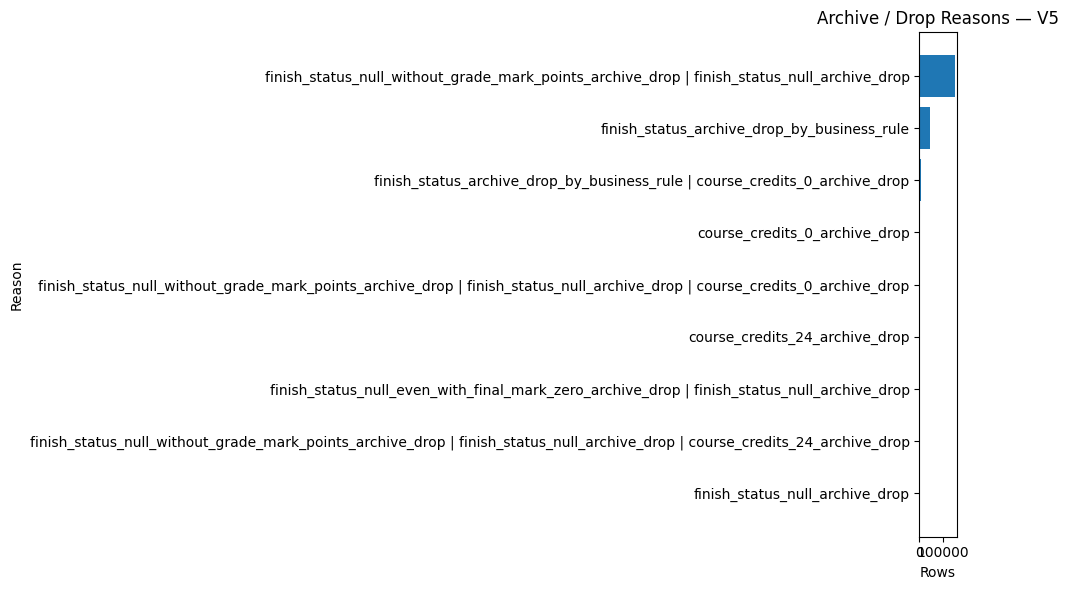

In [ ]:
if len(archive_drop_report_v5) > 0:
    plot_df = archive_drop_report_v5.sort_values("count", ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(plot_df["archive_drop_reason_v5"], plot_df["count"])
    plt.title("Archive / Drop Reasons — V5")
    plt.xlabel("Rows")
    plt.ylabel("Reason")
    plt.tight_layout()
    plt.show()
else:
    print("No archive/drop rows to visualize.")

## 15. Flag critical issues

Critical issues:
- missing `student_id`
- missing `course_id`
- missing `part_id`

Without these IDs, we cannot safely create student-course attempts or current status.


In [33]:
df_flagged_v5["critical_issue_reason_v5"] = ""

append_reason(
    df_flagged_v5,
    df_flagged_v5["student_id"].isna(),
    "critical_issue_reason_v5",
    "missing_student_id_critical",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["course_id"].isna(),
    "critical_issue_reason_v5",
    "missing_course_id_critical",
)

append_reason(
    df_flagged_v5,
    df_flagged_v5["part_id"].isna(),
    "critical_issue_reason_v5",
    "missing_part_id_critical",
)

df_flagged_v5["is_critical_issue"] = (
    df_flagged_v5["critical_issue_reason_v5"]
    .astype("string")
    .str.len()
    .gt(0)
)

critical_issue_rows_v5 = df_flagged_v5[df_flagged_v5["is_critical_issue"]].copy()

critical_issues_report_v5 = (
    critical_issue_rows_v5["critical_issue_reason_v5"]
    .value_counts(dropna=False)
    .reset_index()
)

critical_issues_report_v5.columns = ["critical_issue_reason_v5", "count"]
critical_issues_report_v5["row_count"] = len(df_flagged_v5)
critical_issues_report_v5["ratio"] = critical_issues_report_v5["count"] / len(df_flagged_v5)

critical_issues_report_path_v5 = REPORTS_DIR / "critical_issues_report_v5.csv"
critical_issue_rows_path_v5 = REPORTS_DIR / "critical_issue_rows_v5.csv"

critical_issues_report_v5.to_csv(
    critical_issues_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

critical_issue_rows_v5.to_csv(
    critical_issue_rows_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(critical_issues_report_v5)
print("Critical rows:", len(critical_issue_rows_v5))
print("Saved:", critical_issues_report_path_v5)
print("Saved:", critical_issue_rows_path_v5)

,critical_issue_reason_v5,count,row_count,ratio
0,missing_course_id_critical | missing_part_id_c...,1,960175,0.000001


Critical rows: 1
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\critical_issues_report_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\critical_issue_rows_v5.csv


In [34]:
assert critical_issues_report_path_v5.exists()
assert critical_issue_rows_path_v5.exists()
assert len(critical_issue_rows_v5) == int(df_flagged_v5["is_critical_issue"].sum())

print("Validation passed: critical issue rows flagged and reported.")

Validation passed: critical issue rows flagged and reported.


## 16. Report course_credits null rows without filling them

`course_credits` null values are not filled manually.  
They are reported for data-quality follow-up.


In [35]:
course_credits_null_rows_v5 = df_flagged_v5[df_flagged_v5["course_credits_is_null_v5"]].copy()

course_credits_null_rows_path_v5 = REPORTS_DIR / "course_credits_null_rows_v5.csv"
course_credits_null_rows_v5.to_csv(
    course_credits_null_rows_path_v5,
    index=False,
    encoding="utf-8-sig"
)

course_credits_null_report_v5 = pd.DataFrame([{
    "case": "course_credits_null_not_filled",
    "count": len(course_credits_null_rows_v5),
    "row_count": len(df_flagged_v5),
    "ratio": len(course_credits_null_rows_v5) / len(df_flagged_v5),
}])

course_credits_null_report_path_v5 = REPORTS_DIR / "course_credits_null_report_v5.csv"
course_credits_null_report_v5.to_csv(
    course_credits_null_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(course_credits_null_report_v5)
display(course_credits_null_rows_v5.head(50))

print("Saved:", course_credits_null_rows_path_v5)
print("Saved:", course_credits_null_report_path_v5)

,case,count,row_count,ratio
0,course_credits_null_not_filled,1,960175,0.000001


,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,finish_status_clean,final_mark_numeric_v5,points_float,course_credits_num,course_credits_int,has_fractional_course_credits,course_name_clean,degree_name_clean,study_mode_clean,finish_status_is_null_v5,finish_status_null_without_grade_mark_points_v5,finish_status_null_with_final_mark_zero_v5,final_mark_was_filled_zero_v5,final_mark_clean_v5,final_mark_clean_int_v5,course_credits_is_null_v5,course_name_is_null_v5,degree_name_is_null_v5,is_official_pass,is_transfer_pass,is_internal_performance_attempt,is_fail,is_fail_like,is_withdrawn,is_in_progress,is_unknown_finish_status,archive_drop_reason_v5,is_archive_or_drop,critical_issue_reason_v5,is_critical_issue
213695,1095624.111,3432.111,NaN,NaN,985.111,0.0,0.0,F,NaN,C,2.111,دكتور في الطب,2.111,NaN,A,213695,F,0.0,0.0,NaN,<NA>,False,<NA>,دكتور في الطب,C,False,False,False,False,0.0,0,True,True,False,False,False,True,True,False,False,False,False,,False,missing_course_id_critical | missing_part_id_c...,True


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\course_credits_null_rows_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\course_credits_null_report_v5.csv


In [36]:
assert course_credits_null_rows_path_v5.exists()
assert course_credits_null_report_path_v5.exists()

print("Validation passed: course_credits null rows reported without manual filling.")

Validation passed: course_credits null rows reported without manual filling.


## 17. Create df_attempts_clean_v5

Clean attempts keep only:
- `P`
- `F`
- `FA`
- `FE`
- `W`

And remove/isolate:
- exact duplicates
- archive/drop statuses
- `course_credits == 24`
- `course_credits == 0`
- null `finish_status`
- critical missing IDs


In [37]:
clean_keep_mask_v5 = (
    ~df_flagged_v5["is_archive_or_drop"]
    & ~df_flagged_v5["is_critical_issue"]
    & df_flagged_v5["finish_status_clean"].isin(KEEP_STATUSES_V5)
)

df_attempts_clean_v5 = df_flagged_v5[clean_keep_mask_v5].copy()

removed_or_isolated_count_v5 = len(df_flagged_v5) - len(df_attempts_clean_v5)

print("Raw rows:", len(df_raw_v5))
print("Exact duplicate rows removed:", len(df_duplicate_rows_v5))
print("Rows after duplicates:", len(df_work_v5))
print("Clean rows:", len(df_attempts_clean_v5))
print("Removed / isolated after duplicate step:", removed_or_isolated_count_v5)

display(
    df_attempts_clean_v5["finish_status_clean"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "finish_status_clean", "finish_status_clean": "count"})
)

Raw rows: 965467
Exact duplicate rows removed: 5292
Rows after duplicates: 960175
Clean rows: 749110
Removed / isolated after duplicate step: 211065


,count,count
0,P,615422
1,F,96124
2,W,35885
3,FA,1105
4,FE,574


In [38]:
assert df_attempts_clean_v5["finish_status_clean"].isin(KEEP_STATUSES_V5).all()
assert not df_attempts_clean_v5["is_archive_or_drop"].any()
assert not df_attempts_clean_v5["is_critical_issue"].any()
assert not df_attempts_clean_v5["course_credits_num"].eq(24).any()

if DROP_ZERO_COURSE_CREDITS_V5:
    assert not df_attempts_clean_v5["course_credits_num"].eq(0).any()

assert df_attempts_clean_v5["student_id"].notna().all()
assert df_attempts_clean_v5["course_id"].notna().all()
assert df_attempts_clean_v5["part_id"].notna().all()

print("Validation passed: df_attempts_clean_v5 created using updated rules.")

Validation passed: df_attempts_clean_v5 created using updated rules.


## 18. Define ID normalization helpers

For every ID column, we will create:
- `*_raw`
- `*_base`
- `*_suffix`
- `*_key`

Original ID columns are not overwritten.


In [39]:
ID_COLUMNS_V5 = [
    "student_course_id",
    "student_id",
    "course_id",
    "part_id",
    "grade_id",
    "degree_id",
    "faculty_id",
]


def normalize_id_to_string(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()

    if text == "" or text.lower() in {"nan", "none", "null", "<na>"}:
        return pd.NA

    try:
        decimal_value = Decimal(text)
        normalized = format(decimal_value, "f")

        if "." in normalized:
            normalized = normalized.rstrip("0").rstrip(".")

        return normalized

    except InvalidOperation:
        return text


def add_id_components(df: pd.DataFrame, id_col: str) -> pd.DataFrame:
    result = df.copy()

    raw_col = f"{id_col}_raw"
    str_col = f"{id_col}_str"
    base_col = f"{id_col}_base"
    suffix_col = f"{id_col}_suffix"
    key_col = f"{id_col}_key"

    result[raw_col] = result[id_col]
    result[str_col] = result[id_col].apply(normalize_id_to_string).astype("string")

    split_parts = result[str_col].str.split(".", n=1, expand=True)

    result[base_col] = pd.to_numeric(split_parts[0], errors="coerce").astype("Int64")

    if split_parts.shape[1] > 1:
        result[suffix_col] = split_parts[1].astype("string")
    else:
        result[suffix_col] = pd.Series(pd.NA, index=result.index, dtype="string")

    result[key_col] = result[str_col]

    return result


print("ID columns:", ID_COLUMNS_V5)

ID columns: ['student_course_id', 'student_id', 'course_id', 'part_id', 'grade_id', 'degree_id', 'faculty_id']


In [40]:
for col in ID_COLUMNS_V5:
    assert col in df_attempts_clean_v5.columns, f"Missing ID column: {col}"

print("Validation passed: ID normalization helpers ready.")

Validation passed: ID normalization helpers ready.


## 19. Create df_attempts_normalized_v5

This dataframe starts from `df_attempts_clean_v5` and adds normalized ID columns.  
Original IDs remain preserved.


In [41]:
df_attempts_normalized_v5 = df_attempts_clean_v5.copy()

for id_col in ID_COLUMNS_V5:
    df_attempts_normalized_v5 = add_id_components(df_attempts_normalized_v5, id_col)

id_display_columns_v5 = (
    ID_COLUMNS_V5
    + [f"{col}_raw" for col in ID_COLUMNS_V5]
    + [f"{col}_base" for col in ID_COLUMNS_V5]
    + [f"{col}_suffix" for col in ID_COLUMNS_V5]
    + [f"{col}_key" for col in ID_COLUMNS_V5]
)

display(df_attempts_normalized_v5[id_display_columns_v5].head())

,student_course_id,student_id,course_id,part_id,grade_id,degree_id,faculty_id,student_course_id_raw,student_id_raw,course_id_raw,part_id_raw,grade_id_raw,degree_id_raw,faculty_id_raw,student_course_id_base,student_id_base,course_id_base,part_id_base,grade_id_base,degree_id_base,faculty_id_base,student_course_id_suffix,student_id_suffix,course_id_suffix,part_id_suffix,grade_id_suffix,degree_id_suffix,faculty_id_suffix,student_course_id_key,student_id_key,course_id_key,part_id_key,grade_id_key,degree_id_key,faculty_id_key
0,466289.111,1491.111,153.111,20111.0,684.111,19.111,7.111,466289.111,1491.111,153.111,20111.0,684.111,19.111,7.111,466289,1491,153,20111,684,19,7,111,111,111,<NA>,111,111,111,466289.111,1491.111,153.111,20111,684.111,19.111,7.111
1,466290.111,1491.111,152.111,20111.0,684.111,19.111,7.111,466290.111,1491.111,152.111,20111.0,684.111,19.111,7.111,466290,1491,152,20111,684,19,7,111,111,111,<NA>,111,111,111,466290.111,1491.111,152.111,20111,684.111,19.111,7.111
2,466291.111,1491.111,150.111,20111.0,679.111,19.111,7.111,466291.111,1491.111,150.111,20111.0,679.111,19.111,7.111,466291,1491,150,20111,679,19,7,111,111,111,<NA>,111,111,111,466291.111,1491.111,150.111,20111,679.111,19.111,7.111
3,466292.111,1491.111,149.111,20111.0,676.111,19.111,7.111,466292.111,1491.111,149.111,20111.0,676.111,19.111,7.111,466292,1491,149,20111,676,19,7,111,111,111,<NA>,111,111,111,466292.111,1491.111,149.111,20111,676.111,19.111,7.111
4,466293.111,1492.111,153.111,20111.0,684.111,19.111,7.111,466293.111,1492.111,153.111,20111.0,684.111,19.111,7.111,466293,1492,153,20111,684,19,7,111,111,111,<NA>,111,111,111,466293.111,1492.111,153.111,20111,684.111,19.111,7.111


In [42]:
for id_col in ID_COLUMNS_V5:
    assert id_col in df_attempts_normalized_v5.columns
    assert f"{id_col}_raw" in df_attempts_normalized_v5.columns
    assert f"{id_col}_base" in df_attempts_normalized_v5.columns
    assert f"{id_col}_suffix" in df_attempts_normalized_v5.columns
    assert f"{id_col}_key" in df_attempts_normalized_v5.columns

    original = df_attempts_normalized_v5[id_col]
    raw_copy = df_attempts_normalized_v5[f"{id_col}_raw"]

    assert original.equals(raw_copy), f"{id_col}_raw does not preserve original {id_col}"

assert len(df_attempts_normalized_v5) == len(df_attempts_clean_v5)

print("Validation passed: df_attempts_normalized_v5 created and original IDs preserved.")

Validation passed: df_attempts_normalized_v5 created and original IDs preserved.


## 20. Save ID suffix inspection report

This report checks suffix distribution for all ID columns.  
It helps verify suffixes such as `.111` are preserved.


In [43]:
suffix_reports_v5 = []

for id_col in ID_COLUMNS_V5:
    suffix_col = f"{id_col}_suffix"

    temp = (
        df_attempts_normalized_v5[suffix_col]
        .fillna("<NO_SUFFIX>")
        .value_counts(dropna=False)
        .reset_index()
    )

    temp.columns = ["suffix", "count"]
    temp.insert(0, "id_column", id_col)
    temp["row_count"] = len(df_attempts_normalized_v5)
    temp["ratio"] = temp["count"] / len(df_attempts_normalized_v5)

    suffix_reports_v5.append(temp)

id_suffix_report_v5 = pd.concat(suffix_reports_v5, ignore_index=True)

id_suffix_report_path_v5 = REPORTS_DIR / "id_suffix_report_v5.csv"
id_suffix_report_v5.to_csv(id_suffix_report_path_v5, index=False, encoding="utf-8-sig")

display(id_suffix_report_v5)
print("Saved:", id_suffix_report_path_v5)

,id_column,suffix,count,row_count,ratio
0,student_course_id,111,749107,749110,0.999996
1,student_course_id,101,3,749110,0.000004
2,student_id,111,749110,749110,1.0
3,course_id,111,749110,749110,1.0
4,part_id,<NO_SUFFIX>,749110,749110,1.0
5,grade_id,111,749110,749110,1.0
6,degree_id,111,749110,749110,1.0
7,faculty_id,111,749110,749110,1.0


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\id_suffix_report_v5.csv


In [44]:
assert id_suffix_report_path_v5.exists()
assert set(id_suffix_report_v5["id_column"]) == set(ID_COLUMNS_V5)

print("Validation passed: ID suffix report saved.")

Validation passed: ID suffix report saved.


## 21. Validate normalized academic flags

The normalized dataframe must contain the requested academic flags.


In [45]:
required_flag_columns_v5 = [
    "is_official_pass",
    "is_transfer_pass",
    "is_internal_performance_attempt",
    "is_fail",
    "is_fail_like",
    "is_withdrawn",
    "is_in_progress",
    "is_archive_or_drop",
    "is_critical_issue",
]

flag_summary_v5 = pd.DataFrame({
    "flag": required_flag_columns_v5,
    "true_count": [int(df_attempts_normalized_v5[col].sum()) for col in required_flag_columns_v5],
    "false_count": [int((~df_attempts_normalized_v5[col]).sum()) for col in required_flag_columns_v5],
    "row_count": len(df_attempts_normalized_v5),
})

flag_summary_v5["true_ratio"] = flag_summary_v5["true_count"] / len(df_attempts_normalized_v5)

display(flag_summary_v5)

,flag,true_count,false_count,row_count,true_ratio
0,is_official_pass,615422,133688,749110,0.821538
1,is_transfer_pass,0,749110,749110,0.000000
2,is_internal_performance_attempt,713225,35885,749110,0.952096
3,is_fail,97803,651307,749110,0.130559
4,is_fail_like,1679,747431,749110,0.002241
5,is_withdrawn,35885,713225,749110,0.047904
6,is_in_progress,0,749110,749110,0.000000
7,is_archive_or_drop,0,749110,749110,0.000000
8,is_critical_issue,0,749110,749110,0.000000


In [46]:
for col in required_flag_columns_v5:
    assert col in df_attempts_normalized_v5.columns, f"Missing flag column: {col}"

assert not df_attempts_normalized_v5["is_archive_or_drop"].any()
assert not df_attempts_normalized_v5["is_critical_issue"].any()
assert not df_attempts_normalized_v5["is_transfer_pass"].any()
assert "is_last_try" not in df_attempts_normalized_v5.columns

print("Validation passed: required flags exist and clean data has no archive/critical rows.")

Validation passed: required flags exist and clean data has no archive/critical rows.


## 22. Validate that no pass/fail logic comes from marks

This check confirms that official pass/fail flags are based only on `finish_status_clean`.


In [47]:
expected_is_official_pass_v5 = (
    df_attempts_normalized_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
)

expected_is_fail_v5 = (
    df_attempts_normalized_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

mismatch_official_pass_v5 = (
    df_attempts_normalized_v5["is_official_pass"] != expected_is_official_pass_v5
).sum()

mismatch_fail_v5 = (
    df_attempts_normalized_v5["is_fail"] != expected_is_fail_v5
).sum()

print("Official pass mismatches:", mismatch_official_pass_v5)
print("Fail mismatches:", mismatch_fail_v5)

Official pass mismatches: 0
Fail mismatches: 0


In [48]:
assert mismatch_official_pass_v5 == 0, "is_official_pass is not aligned with finish_status rules."
assert mismatch_fail_v5 == 0, "is_fail is not aligned with finish_status rules."

print("Validation passed: pass/fail logic comes only from finish_status.")

Validation passed: pass/fail logic comes only from finish_status.


## 23. Calculate attempts manually

Because `is_last_try` is not available and was not reliable, attempts are calculated manually.

Logic:
- Group by `student_id_key` + `course_id_key`.
- Sort attempts by `student_course_id_base`.
- `attempt_number_v5` starts from 1.
- `attempt_count_v5` is total attempts per student-course.
- First and last attempt flags are calculated manually.


In [49]:
student_course_attempt_key_cols_v5 = [
    "student_id_key",
    "course_id_key",
]

df_attempts_normalized_v5 = df_attempts_normalized_v5.sort_values(
    student_course_attempt_key_cols_v5
    + [
        "student_course_id_base",
        "_source_row_number_v5",
    ],
    ascending=[True, True, True, True],
    na_position="last",
).copy()

df_attempts_normalized_v5["attempt_number_v5"] = (
    df_attempts_normalized_v5
    .groupby(student_course_attempt_key_cols_v5, dropna=False)
    .cumcount()
    + 1
)

df_attempts_normalized_v5["attempt_count_v5"] = (
    df_attempts_normalized_v5
    .groupby(student_course_attempt_key_cols_v5, dropna=False)["student_course_id_key"]
    .transform("count")
)

df_attempts_normalized_v5["is_first_attempt_calculated_v5"] = (
    df_attempts_normalized_v5["attempt_number_v5"].eq(1)
)

df_attempts_normalized_v5["is_last_attempt_calculated_v5"] = (
    df_attempts_normalized_v5["attempt_number_v5"]
    .eq(df_attempts_normalized_v5["attempt_count_v5"])
)

display(df_attempts_normalized_v5[[
    "student_id_key",
    "course_id_key",
    "student_course_id",
    "student_course_id_base",
    "finish_status_clean",
    "attempt_number_v5",
    "attempt_count_v5",
    "is_first_attempt_calculated_v5",
    "is_last_attempt_calculated_v5",
]].head(50))

,student_id_key,course_id_key,student_course_id,student_course_id_base,finish_status_clean,attempt_number_v5,attempt_count_v5,is_first_attempt_calculated_v5,is_last_attempt_calculated_v5
149587,10000.111,1016.111,939272.111,939272,P,1,1,True,True
132234,10000.111,1017.111,953865.111,953865,P,1,1,True,True
253026,10000.111,1019.111,1076397.111,1076397,P,1,1,True,True
93238,10000.111,431.111,925010.111,925010,P,1,1,True,True
67489,10000.111,432.111,901340.111,901340,P,1,1,True,True
99537,10000.111,433.111,973921.111,973921,P,1,1,True,True
141346,10000.111,434.111,949219.111,949219,P,1,1,True,True
253025,10000.111,435.111,1076396.111,1076396,P,1,1,True,True
270788,10000.111,436.111,1131540.111,1131540,P,1,1,True,True
319141,10000.111,437.111,1192637.111,1192637,P,1,1,True,True


In [50]:
last_attempt_check_v5 = (
    df_attempts_normalized_v5
    .groupby(student_course_attempt_key_cols_v5, dropna=False)["is_last_attempt_calculated_v5"]
    .sum()
    .reset_index(name="last_attempt_count")
)

first_attempt_check_v5 = (
    df_attempts_normalized_v5
    .groupby(student_course_attempt_key_cols_v5, dropna=False)["is_first_attempt_calculated_v5"]
    .sum()
    .reset_index(name="first_attempt_count")
)

assert last_attempt_check_v5["last_attempt_count"].eq(1).all(), \
    "Each student-course must have exactly one calculated last attempt."

assert first_attempt_check_v5["first_attempt_count"].eq(1).all(), \
    "Each student-course must have exactly one calculated first attempt."

manual_attempts_report_v5 = (
    df_attempts_normalized_v5["attempt_count_v5"]
    .value_counts()
    .sort_index()
    .reset_index()
)

manual_attempts_report_v5.columns = ["attempt_count_v5", "student_course_rows"]
manual_attempts_report_path_v5 = REPORTS_DIR / "manual_attempts_report_v5.csv"
manual_attempts_report_v5.to_csv(
    manual_attempts_report_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(manual_attempts_report_v5)
print("Saved:", manual_attempts_report_path_v5)

assert manual_attempts_report_path_v5.exists()

print("Validation passed: manual attempt calculation is correct.")

,attempt_count_v5,student_course_rows
0,1,536731
1,2,122430
2,3,46983
3,4,20600
4,5,10930
5,6,5310
6,7,2849
7,8,1624
8,9,810
9,10,400


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\manual_attempts_report_v5.csv
Validation passed: manual attempt calculation is correct.


## 24. Create df_student_course_current_status_v5

Current status is created from the calculated last attempt only.  
No `is_last_try` column is used.


In [51]:
df_student_course_current_status_v5 = (
    df_attempts_normalized_v5[
        df_attempts_normalized_v5["is_last_attempt_calculated_v5"]
    ]
    .copy()
)

df_student_course_current_status_v5["current_status_v5"] = np.select(
    [
        df_student_course_current_status_v5["finish_status_clean"].isin(PASS_STATUSES_V5),
        df_student_course_current_status_v5["finish_status_clean"].isin(FAIL_STATUSES_V5),
        df_student_course_current_status_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5),
    ],
    [
        "passed",
        "failed",
        "withdrawn",
    ],
    default="review",
)

df_student_course_current_status_v5["current_is_passed_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(PASS_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_failed_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(FAIL_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_withdrawn_v5"] = (
    df_student_course_current_status_v5["finish_status_clean"].isin(WITHDRAWN_STATUSES_V5)
)

df_student_course_current_status_v5["current_is_transfer_v5"] = False
df_student_course_current_status_v5["current_is_in_progress_v5"] = False

display(df_student_course_current_status_v5.head())

,student_course_id,student_id,course_id,part_id,grade_id,final_mark,points,finish_status,course_name_sl,study_mode,degree_id,degree_name_sl,faculty_id,course_credits,active,_source_row_number_v5,finish_status_clean,final_mark_numeric_v5,points_float,course_credits_num,course_credits_int,has_fractional_course_credits,course_name_clean,degree_name_clean,study_mode_clean,finish_status_is_null_v5,finish_status_null_without_grade_mark_points_v5,finish_status_null_with_final_mark_zero_v5,final_mark_was_filled_zero_v5,final_mark_clean_v5,final_mark_clean_int_v5,course_credits_is_null_v5,course_name_is_null_v5,degree_name_is_null_v5,is_official_pass,is_transfer_pass,is_internal_performance_attempt,is_fail,is_fail_like,is_withdrawn,is_in_progress,is_unknown_finish_status,archive_drop_reason_v5,is_archive_or_drop,critical_issue_reason_v5,is_critical_issue,student_course_id_raw,student_course_id_str,student_course_id_base,student_course_id_suffix,student_course_id_key,student_id_raw,student_id_str,student_id_base,student_id_suffix,student_id_key,course_id_raw,course_id_str,course_id_base,course_id_suffix,course_id_key,part_id_raw,part_id_str,part_id_base,part_id_suffix,part_id_key,grade_id_raw,grade_id_str,grade_id_base,grade_id_suffix,grade_id_key,degree_id_raw,degree_id_str,degree_id_base,degree_id_suffix,degree_id_key,faculty_id_raw,faculty_id_str,faculty_id_base,faculty_id_suffix,faculty_id_key,attempt_number_v5,attempt_count_v5,is_first_attempt_calculated_v5,is_last_attempt_calculated_v5,current_status_v5,current_is_passed_v5,current_is_failed_v5,current_is_withdrawn_v5,current_is_transfer_v5,current_is_in_progress_v5
149587,939272.111,10000.111,1016.111,20152.0,677.111,82.0,3.00,P,المنطق والتفكير العلمي,C,3.111,هندسة البرمجيات ونظم المعلومات,5.111,2.0,A,149587,P,82.0,3.00,2.0,2,False,المنطق والتفكير العلمي,هندسة البرمجيات ونظم المعلومات,C,False,False,False,False,82.0,82,False,False,False,True,False,True,False,False,False,False,False,,False,,False,939272.111,939272.111,939272,111,939272.111,10000.111,10000.111,10000,111,10000.111,1016.111,1016.111,1016,111,1016.111,20152.0,20152,20152,<NA>,20152,677.111,677.111,677,111,677.111,3.111,3.111,3,111,3.111,5.111,5.111,5,111,5.111,1,1,True,True,passed,True,False,False,False,False
132234,953865.111,10000.111,1017.111,20153.0,680.111,67.0,2.25,P,لغة اجنبية حية (ثانية),C,3.111,هندسة البرمجيات ونظم المعلومات,5.111,2.0,A,132234,P,67.0,2.25,2.0,2,False,لغة اجنبية حية (ثانية),هندسة البرمجيات ونظم المعلومات,C,False,False,False,False,67.0,67,False,False,False,True,False,True,False,False,False,False,False,,False,,False,953865.111,953865.111,953865,111,953865.111,10000.111,10000.111,10000,111,10000.111,1017.111,1017.111,1017,111,1017.111,20153.0,20153,20153,<NA>,20153,680.111,680.111,680,111,680.111,3.111,3.111,3,111,3.111,5.111,5.111,5,111,5.111,1,1,True,True,passed,True,False,False,False,False
253026,1076397.111,10000.111,1019.111,20171.0,981.111,66.0,2.25,P,مدخل الى القانون,C,3.111,هندسة البرمجيات ونظم المعلومات,5.111,2.0,A,253026,P,66.0,2.25,2.0,2,False,مدخل الى القانون,هندسة البرمجيات ونظم المعلومات,C,False,False,False,False,66.0,66,False,False,False,True,False,True,False,False,False,False,False,,False,,False,1076397.111,1076397.111,1076397,111,1076397.111,10000.111,10000.111,10000,111,10000.111,1019.111,1019.111,1019,111,1019.111,20171.0,20171,20171,<NA>,20171,981.111,981.111,981,111,981.111,3.111,3.111,3,111,3.111,5.111,5.111,5,111,5.111,1,1,True,True,passed,True,False,False,False,False
93238,925010.111,10000.111,431.111,20152.0,677.111,83.0,3.00,P,الرياضيات المتقطعة,C,3.111,هندسة البرمجيات ونظم المعلومات,5.111,3.0,A,93238,P,83.0,3.00,3.0,3,False,الرياضيات المتقطعة,هندسة البرمجيات ونظم المعلومات,C,False,False,False,False,83.0,83,False,False,False,True,False,True,False,False,False,False,False,,False,,False,925010.111,925010.111,925010,111,925010.111,10000.111,10000.111,10000,111,10000.111,431.111,431.111,431,111,431.111,20152.0,20152,20152,<NA>,20152,677.111,677.111,677,111,677.111,3.111,3.111,

In [52]:
current_duplicates_v5 = df_student_course_current_status_v5.duplicated(
    subset=student_course_attempt_key_cols_v5
).sum()

print("Current status rows:", len(df_student_course_current_status_v5))
print("Duplicate student-course current rows:", current_duplicates_v5)

assert current_duplicates_v5 == 0, "Current status has duplicate student-course rows."
assert df_student_course_current_status_v5["student_id_key"].notna().all()
assert df_student_course_current_status_v5["course_id_key"].notna().all()
assert "is_last_try" not in df_student_course_current_status_v5.columns

print("Validation passed: one current status per student-course combination.")

Current status rows: 622606
Duplicate student-course current rows: 0
Validation passed: one current status per student-course combination.


## 25. Current status distribution

This visualization checks the final current academic status distribution.


In [53]:
current_status_distribution_v5 = (
    df_student_course_current_status_v5["current_status_v5"]
    .value_counts(dropna=False)
    .reset_index()
)

current_status_distribution_v5.columns = ["current_status_v5", "count"]
current_status_distribution_v5["row_count"] = len(df_student_course_current_status_v5)
current_status_distribution_v5["ratio"] = (
    current_status_distribution_v5["count"] / len(df_student_course_current_status_v5)
)

current_status_distribution_path_v5 = REPORTS_DIR / "current_status_distribution_v5.csv"
current_status_distribution_v5.to_csv(
    current_status_distribution_path_v5,
    index=False,
    encoding="utf-8-sig"
)

display(current_status_distribution_v5)
print("Saved:", current_status_distribution_path_v5)

,current_status_v5,count,row_count,ratio
0,passed,592583,622606,0.951778
1,failed,16578,622606,0.026627
2,withdrawn,13445,622606,0.021595


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\current_status_distribution_v5.csv


In [54]:
assert current_status_distribution_path_v5.exists()
assert current_status_distribution_v5["count"].sum() == len(df_student_course_current_status_v5)

print("Validation passed: current status distribution is consistent.")

Validation passed: current status distribution is consistent.


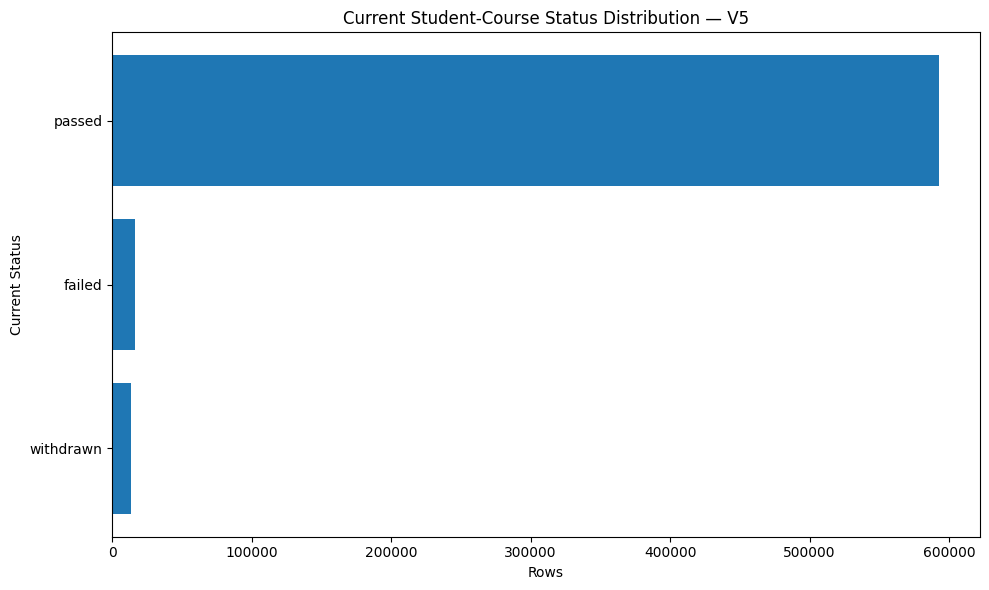

In [55]:
plot_df = current_status_distribution_v5.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["current_status_v5"], plot_df["count"])
plt.title("Current Student-Course Status Distribution — V5")
plt.xlabel("Rows")
plt.ylabel("Current Status")
plt.tight_layout()
plt.show()

## 26. Save final outputs

Main storage format is Parquet.  
CSV is saved as optional inspection export.


In [56]:
df_attempts_clean_parquet_path_v5 = (
    PREPROCESSED_DIR / "df_attempts_clean_v5.parquet"
)

df_attempts_clean_csv_path_v5 = (
    PREPROCESSED_DIR / "df_attempts_clean_v5.csv"
)

df_attempts_normalized_parquet_path_v5 = (
    PREPROCESSED_DIR / "df_attempts_normalized_v5.parquet"
)

df_attempts_normalized_csv_path_v5 = (
    PREPROCESSED_DIR / "df_attempts_normalized_v5.csv"
)

df_current_status_parquet_path_v5 = (
    FEATURES_DIR / "df_student_course_current_status_v5.parquet"
)

df_current_status_csv_path_v5 = (
    FEATURES_DIR / "df_student_course_current_status_v5.csv"
)

df_attempts_clean_v5.to_parquet(df_attempts_clean_parquet_path_v5, index=False)
df_attempts_clean_v5.to_csv(df_attempts_clean_csv_path_v5, index=False, encoding="utf-8-sig")

df_attempts_normalized_v5.to_parquet(df_attempts_normalized_parquet_path_v5, index=False)
df_attempts_normalized_v5.to_csv(df_attempts_normalized_csv_path_v5, index=False, encoding="utf-8-sig")

df_student_course_current_status_v5.to_parquet(df_current_status_parquet_path_v5, index=False)
df_student_course_current_status_v5.to_csv(df_current_status_csv_path_v5, index=False, encoding="utf-8-sig")

print("Saved:", df_attempts_clean_parquet_path_v5)
print("Saved:", df_attempts_clean_csv_path_v5)
print("Saved:", df_attempts_normalized_parquet_path_v5)
print("Saved:", df_attempts_normalized_csv_path_v5)
print("Saved:", df_current_status_parquet_path_v5)
print("Saved:", df_current_status_csv_path_v5)

Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_clean_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_clean_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_normalized_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\data\preprocessed\V_CRG_STUDENT_COURSE\df_attempts_normalized_v5.csv
Saved: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE\df_student_course_current_status_v5.parquet
Saved: D:\AI\Real projects\Academic_Advisor\data\features\V_CRG_STUDENT_COURSE\df_student_course_current_status_v5.csv


In [57]:
required_output_paths_v5 = [
    df_attempts_clean_parquet_path_v5,
    df_attempts_clean_csv_path_v5,
    df_attempts_normalized_parquet_path_v5,
    df_attempts_normalized_csv_path_v5,
    df_current_status_parquet_path_v5,
    df_current_status_csv_path_v5,
]

for path in required_output_paths_v5:
    assert path.exists(), f"Missing output file: {path}"

print("Validation passed: all final output files saved.")

Validation passed: all final output files saved.


## 27. Save final validation summary report

This report summarizes the main validation checks and final row counts.


In [58]:
validation_summary_v5 = pd.DataFrame([
    {
        "check_name": "raw_file_exists",
        "status": RAW_PATH.exists(),
        "value": str(RAW_PATH),
    },
    {
        "check_name": "raw_rows",
        "status": len(df_raw_v5) > 0,
        "value": len(df_raw_v5),
    },
    {
        "check_name": "is_last_try_not_used",
        "status": "is_last_try" not in df_raw_v5.columns,
        "value": "is_last_try removed from required columns and workflow",
    },
    {
        "check_name": "required_columns_exist",
        "status": len(missing_required_columns_v5) == 0,
        "value": str(missing_required_columns_v5),
    },
    {
        "check_name": "final_mark_integer_like",
        "status": final_mark_fractional == 0,
        "value": final_mark_fractional,
    },
    {
        "check_name": "course_credits_fractional_rows_reported",
        "status": fractional_course_credits_rows_path_v5.exists(),
        "value": int(course_credits_fractional),
    },
    {
        "check_name": "exact_duplicates_reported",
        "status": duplicate_rows_path_v5.exists(),
        "value": len(df_duplicate_rows_v5),
    },
    {
        "check_name": "null_handling_report_saved",
        "status": null_handling_report_path_v5.exists(),
        "value": str(null_handling_report_path_v5),
    },
    {
        "check_name": "finish_status_null_rows_archived",
        "status": not df_attempts_clean_v5["finish_status_clean"].isna().any(),
        "value": int(df_flagged_v5["finish_status_is_null_v5"].sum()),
    },
    {
        "check_name": "course_credits_null_rows_reported_not_filled",
        "status": course_credits_null_report_path_v5.exists(),
        "value": len(course_credits_null_rows_v5),
    },
    {
        "check_name": "archive_drop_rows_flagged",
        "status": archive_drop_report_path_v5.exists(),
        "value": int(df_flagged_v5["is_archive_or_drop"].sum()),
    },
    {
        "check_name": "critical_issue_rows_flagged",
        "status": critical_issues_report_path_v5.exists(),
        "value": int(df_flagged_v5["is_critical_issue"].sum()),
    },
    {
        "check_name": "clean_rows",
        "status": len(df_attempts_clean_v5) > 0,
        "value": len(df_attempts_clean_v5),
    },
    {
        "check_name": "clean_statuses_are_only_p_f_fa_fe_w",
        "status": df_attempts_clean_v5["finish_status_clean"].isin(KEEP_STATUSES_V5).all(),
        "value": sorted(df_attempts_clean_v5["finish_status_clean"].dropna().unique().tolist()),
    },
    {
        "check_name": "normalized_rows_equal_clean_rows",
        "status": len(df_attempts_normalized_v5) == len(df_attempts_clean_v5),
        "value": f"{len(df_attempts_normalized_v5)} == {len(df_attempts_clean_v5)}",
    },
    {
        "check_name": "manual_attempts_calculated",
        "status": (
            "attempt_number_v5" in df_attempts_normalized_v5.columns
            and "is_last_attempt_calculated_v5" in df_attempts_normalized_v5.columns
        ),
        "value": "attempt_number_v5 / attempt_count_v5 / calculated first-last flags",
    },
    {
        "check_name": "current_status_one_row_per_student_course",
        "status": current_duplicates_v5 == 0,
        "value": current_duplicates_v5,
    },
    {
        "check_name": "no_pass_logic_from_final_mark",
        "status": mismatch_official_pass_v5 == 0,
        "value": mismatch_official_pass_v5,
    },
    {
        "check_name": "df_attempts_clean_v5_saved",
        "status": df_attempts_clean_parquet_path_v5.exists(),
        "value": str(df_attempts_clean_parquet_path_v5),
    },
    {
        "check_name": "df_attempts_normalized_v5_saved",
        "status": df_attempts_normalized_parquet_path_v5.exists(),
        "value": str(df_attempts_normalized_parquet_path_v5),
    },
    {
        "check_name": "df_student_course_current_status_v5_saved",
        "status": df_current_status_parquet_path_v5.exists(),
        "value": str(df_current_status_parquet_path_v5),
    },
])

validation_summary_path_v5 = REPORTS_DIR / "validation_summary_v5.csv"
validation_summary_v5.to_csv(validation_summary_path_v5, index=False, encoding="utf-8-sig")

display(validation_summary_v5)
print("Saved:", validation_summary_path_v5)

,check_name,status,value
0,raw_file_exists,True,D:\AI\Real projects\Academic_Advisor\data\raw\...
1,raw_rows,True,965467
2,is_last_try_not_used,True,is_last_try removed from required columns and ...
3,required_columns_exist,True,[]
4,final_mark_integer_like,True,0.0
5,course_credits_fractional_rows_reported,True,9407
6,exact_duplicates_reported,True,5292
7,null_handling_report_saved,True,D:\AI\Real projects\Academic_Advisor\reports\V...
8,finish_status_null_rows_archived,True,154774
9,course_credits_null_rows_reported_not_filled,True,1


Saved: D:\AI\Real projects\Academic_Advisor\reports\V_CRG_STUDENT_COURSE\validation_summary_v5.csv


In [59]:
assert validation_summary_path_v5.exists()
assert validation_summary_v5["status"].all(), "Some validation checks failed."

print("V5 preprocessing completed successfully.")
print("Created: df_attempts_clean_v5")
print("Created: df_attempts_normalized_v5")
print("Created: df_student_course_current_status_v5")
print("No is_last_try used.")
print("Manual attempt calculation completed.")
print("No models built.")
print("No course difficulty built.")
print("No recommendation logic built.")

V5 preprocessing completed successfully.
Created: df_attempts_clean_v5
Created: df_attempts_normalized_v5
Created: df_student_course_current_status_v5
No is_last_try used.
Manual attempt calculation completed.
No models built.
No course difficulty built.
No recommendation logic built.
